# Allegra the Barman — Scheduling Analysis
**CSC3002F 2026 — OS2 Assignment**

Run all cells top-to-bottom (`Cell → Run All`).
Place this notebook in the same folder as your `results/` directory.

Install once if needed:
```
pip install pandas matplotlib seaborn scipy
```

In [1]:
import glob, os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

PALETTE         = {"FCFS": "#4C72B0", "SJF": "#DD8452",
                   "PRIORITY": "#55A868", "MLFQ": "#C44E52"}
SCHEDULER_ORDER = ["FCFS", "SJF", "PRIORITY", "MLFQ"]

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 130, "savefig.bbox": "tight"})

RESULTS_DIR = "results"   # folder containing FCFS.csv, SJF.csv, etc.
OUT_DIR     = "plots"
os.makedirs(OUT_DIR, exist_ok=True)
print("Setup complete.")

Setup complete.


## 1. Load Data

In [2]:
files = glob.glob(os.path.join(RESULTS_DIR, "*.csv"))
if not files:
    raise FileNotFoundError(
        f"No CSV files found in '{RESULTS_DIR}'. "
        "Make sure FCFS.csv / SJF.csv / PRIORITY.csv / MLFQ.csv are there.")

frames = []
for f in files:
    try:
        # skipinitialspace strips the leading spaces from column names
        tmp = pd.read_csv(f, skipinitialspace=True)
        frames.append(tmp)
        print(f"  Loaded {len(tmp):>6,} rows  ←  {os.path.basename(f)}")
    except Exception as e:
        print(f"  SKIPPED {f}: {e}")

df = pd.concat(frames, ignore_index=True)

# Drop any accidental duplicate header rows
df = df[df["scheduler"] != "scheduler"].copy()

# Ensure numeric types
NUM = ["patronID","execTime","arrivalTime","serviceStartTime",
       "completionTime","waitingTime","responseTime","turnaroundTime","queueLevel"]
for c in NUM:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df.dropna(subset=["waitingTime","responseTime","turnaroundTime"], inplace=True)

df["scheduler"] = pd.Categorical(
    df["scheduler"], categories=SCHEDULER_ORDER, ordered=True)

print(f"\nTotal rows : {len(df):,}")
print(f"Schedulers : {df['scheduler'].unique().tolist()}")
print(f"Columns    : {df.columns.tolist()}")
df.head(3)

  Loaded 36,284 rows  ←  FCFS.csv
  Loaded 33,577 rows  ←  MLFQ.csv
  Loaded 33,577 rows  ←  PRIORITY.csv
  Loaded 35,797 rows  ←  SJF.csv

Total rows : 139,235
Schedulers : ['FCFS', 'MLFQ', 'PRIORITY', 'SJF']
Columns    : ['scheduler', 'patronID', 'drinkName', 'execTime', 'arrivalTime', 'serviceStartTime', 'completionTime', 'waitingTime', 'responseTime', 'turnaroundTime', 'queueLevel']


,scheduler,patronID,drinkName,execTime,arrivalTime,serviceStartTime,completionTime,waitingTime,responseTime,turnaroundTime,queueLevel
0,FCFS,0,Cider,25,1778876489334,1778876489336,1778876489365,2,2,31,0
1,FCFS,1,Margarita,75,1778876489334,1778876489422,1778876489765,88,88,431,0
2,FCFS,0,White Wine,25,1778876489796,1778876490039,1778876490080,243,243,284,0


## 2. Summary Statistics

In [3]:
rows = []
for sched in SCHEDULER_ORDER:
    sub = df[df["scheduler"] == sched]
    if sub.empty:
        continue
    for m in ["waitingTime", "responseTime", "turnaroundTime"]:
        rows.append({
            "Scheduler": sched,
            "Metric"   : m,
            "Mean"  : round(sub[m].mean(),   1),
            "Median": round(sub[m].median(), 1),
            "Std"   : round(sub[m].std(),    1),
            "Min"   : round(sub[m].min(),    1),
            "Max"   : round(sub[m].max(),    1),
        })

summary = pd.DataFrame(rows)
summary.to_csv(os.path.join(OUT_DIR, "summary_stats.csv"), index=False)
summary

,Scheduler,Metric,Mean,Median,Std,Min,Max
0,FCFS,waitingTime,13475.1,11496.5,10661.3,0,36666
1,FCFS,responseTime,13475.1,11496.5,10661.3,0,36666
2,FCFS,turnaroundTime,13533.6,11554.5,10661.5,20,36767
3,SJF,waitingTime,9411.9,95.0,20626.7,0,123249
4,SJF,responseTime,9411.9,95.0,20626.7,0,123249
5,SJF,turnaroundTime,9469.7,147.0,20655.8,20,123449
6,PRIORITY,waitingTime,9833.1,76.0,26977.9,0,157520
7,PRIORITY,responseTime,9833.1,76.0,26977.9,0,157520
8,PRIORITY,turnaroundTime,9891.3,145.0,26978.0,20,157595
9,MLFQ,waitingTime,12829.2,10764.0,10487.1,0,37233


## 3. Waiting Time

C:\Users\Anele Z Ngxongo\AppData\Local\Temp\ipykernel_53100\3854871246.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="scheduler", y="waitingTime", order=SCHEDULER_ORDER,
C:\Users\Anele Z Ngxongo\AppData\Local\Temp\ipykernel_53100\3854871246.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x="scheduler", y="waitingTime", order=SCHEDULER_ORDER,


Saved → plots/waitingTime_box.png


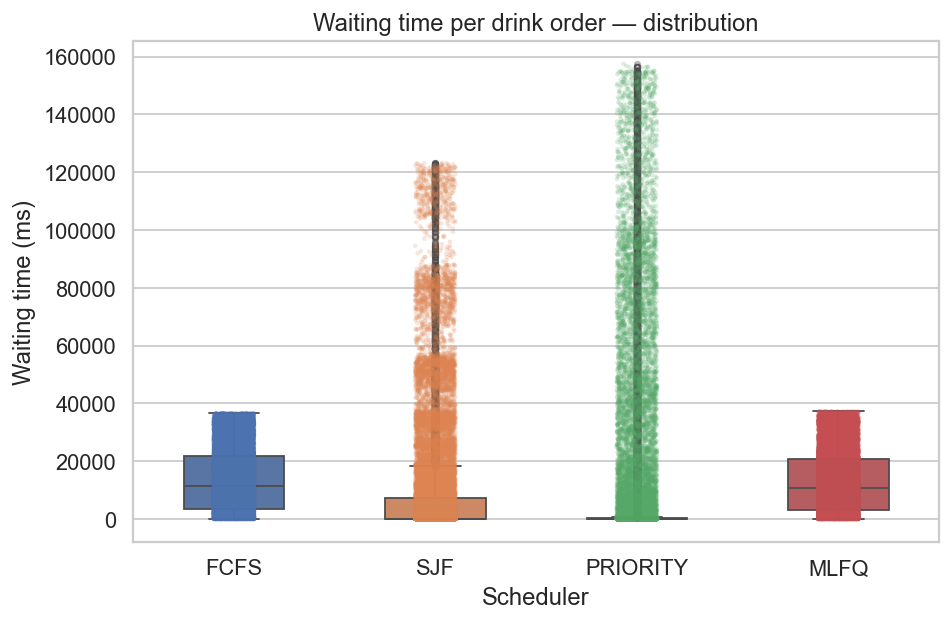

C:\Users\Anele Z Ngxongo\AppData\Local\Temp\ipykernel_53100\3854871246.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="scheduler", y="waitingTime", order=SCHEDULER_ORDER,


Saved → plots/waitingTime_violin.png


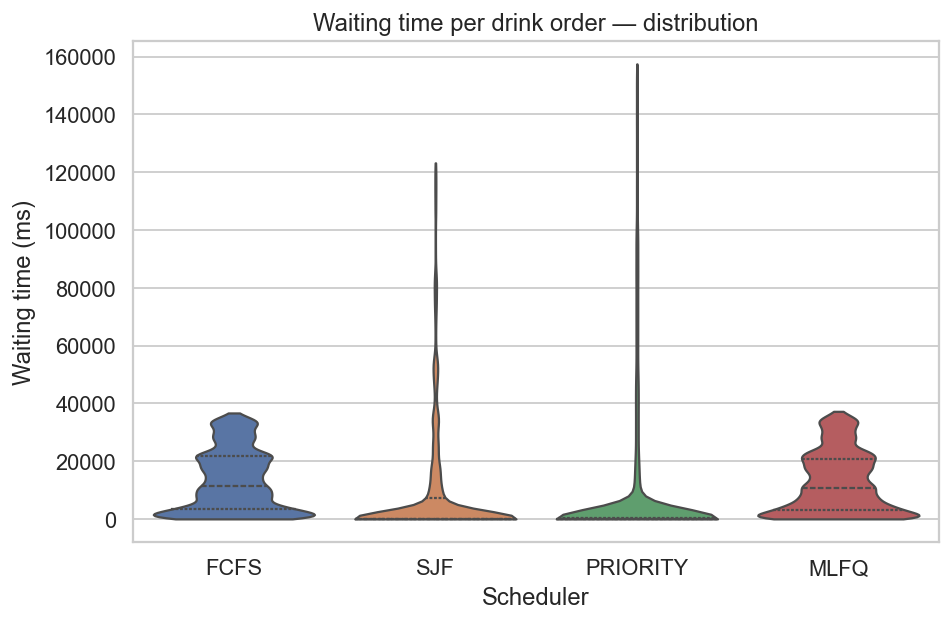

Saved → plots/waitingTime_meanmedian.png


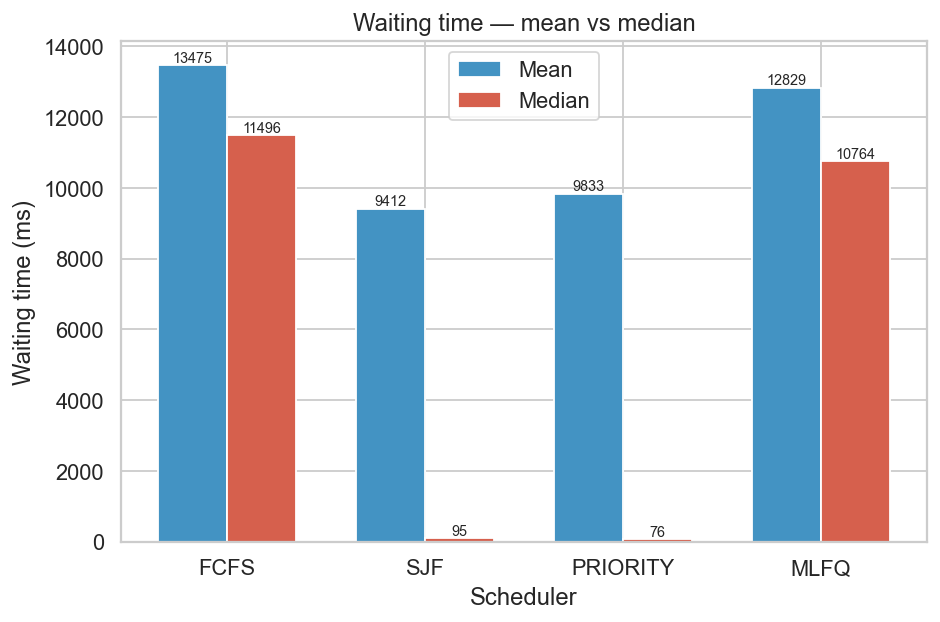

In [4]:

def save(fig, name):
    fig.savefig(os.path.join(OUT_DIR, name))
    print(f"Saved → plots/{name}")

# Box + strip
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df, x="scheduler", y="waitingTime", order=SCHEDULER_ORDER,
            palette=PALETTE, width=0.5,
            flierprops={"marker":".", "alpha":0.4}, ax=ax)
sns.stripplot(data=df, x="scheduler", y="waitingTime", order=SCHEDULER_ORDER,
              palette=PALETTE, size=2.5, alpha=0.2, jitter=True, ax=ax)
ax.set_title("Waiting time per drink order — distribution")
ax.set_xlabel("Scheduler"); ax.set_ylabel("Waiting time (ms)")
save(fig, "waitingTime_box.png"); plt.show()

# Violin
fig, ax = plt.subplots(figsize=(8,5))
sns.violinplot(data=df, x="scheduler", y="waitingTime", order=SCHEDULER_ORDER,
               palette=PALETTE, inner="quartile", cut=0, ax=ax)
ax.set_title("Waiting time per drink order — distribution")
ax.set_xlabel("Scheduler"); ax.set_ylabel("Waiting time (ms)")
save(fig, "waitingTime_violin.png"); plt.show()

# Mean vs Median bar
stats = (df.groupby("scheduler", observed=True)["waitingTime"]
           .agg(Mean="mean", Median="median")
           .reindex(SCHEDULER_ORDER).reset_index())
fig, ax = plt.subplots(figsize=(8,5))
x, w = np.arange(len(SCHEDULER_ORDER)), 0.35
b1 = ax.bar(x-w/2, stats["Mean"],   w, label="Mean",   color="#4393C3")
b2 = ax.bar(x+w/2, stats["Median"], w, label="Median", color="#D6604D")
ax.set_xticks(x); ax.set_xticklabels(SCHEDULER_ORDER)
ax.set_title("Waiting time — mean vs median")
ax.set_xlabel("Scheduler"); ax.set_ylabel("Waiting time (ms)"); ax.legend()
for bar in list(b1)+list(b2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+1, f"{h:.0f}",
            ha="center", va="bottom", fontsize=8)
save(fig, "waitingTime_meanmedian.png"); plt.show()

## 4. Response Time

C:\Users\Anele Z Ngxongo\AppData\Local\Temp\ipykernel_53100\3918396141.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="scheduler", y="responseTime", order=SCHEDULER_ORDER,
C:\Users\Anele Z Ngxongo\AppData\Local\Temp\ipykernel_53100\3918396141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x="scheduler", y="responseTime", order=SCHEDULER_ORDER,


Saved → plots/responseTime_box.png


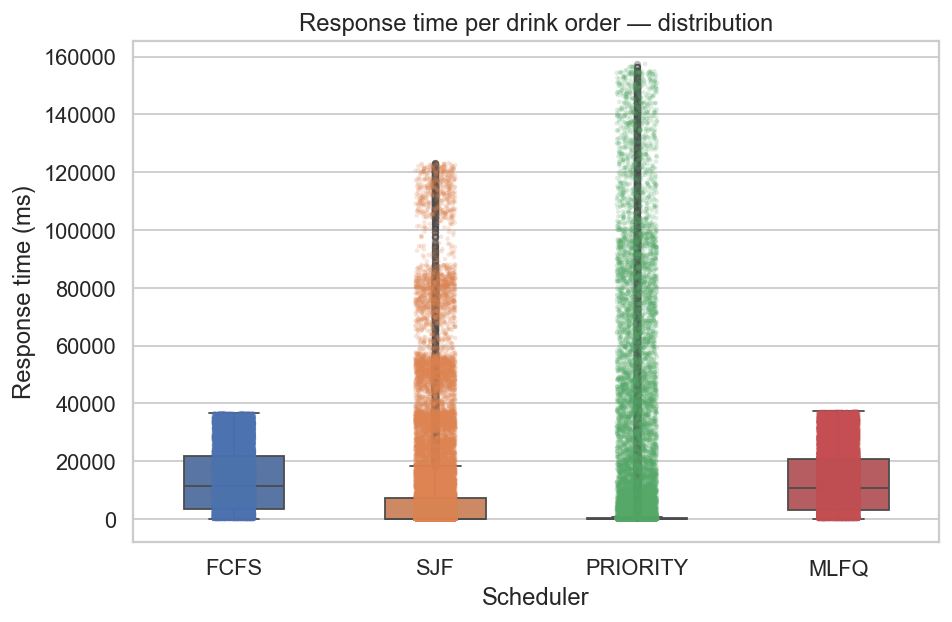

C:\Users\Anele Z Ngxongo\AppData\Local\Temp\ipykernel_53100\3918396141.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="scheduler", y="responseTime", order=SCHEDULER_ORDER,


Saved → plots/responseTime_violin.png


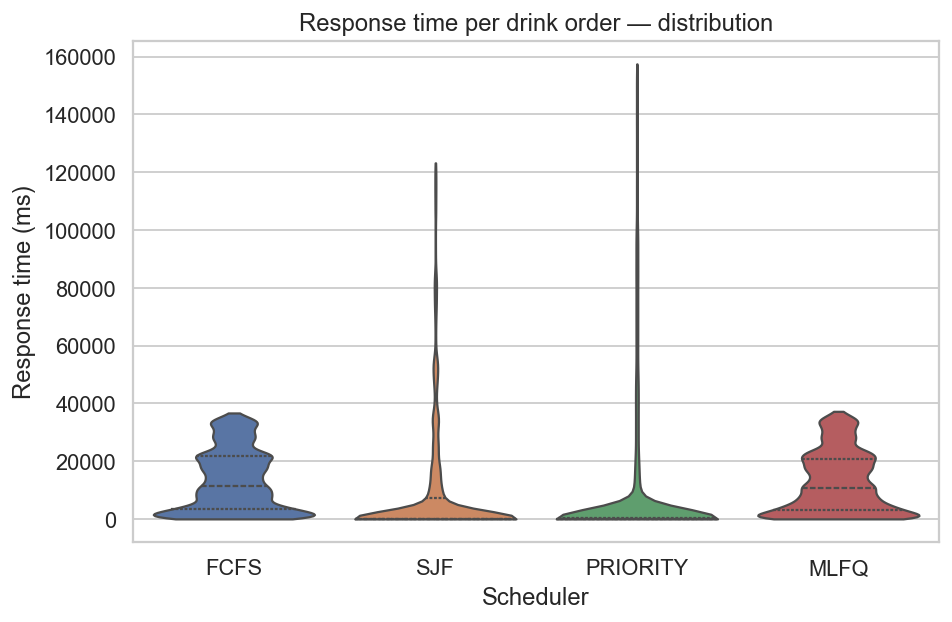

Saved → plots/responseTime_meanmedian.png


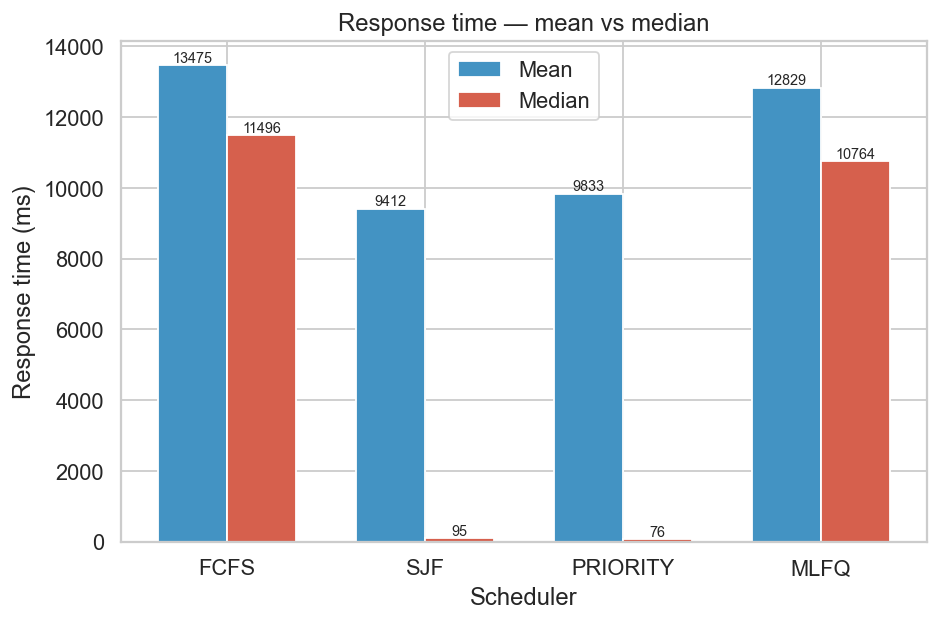

In [5]:
# Box + strip
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df, x="scheduler", y="responseTime", order=SCHEDULER_ORDER,
            palette=PALETTE, width=0.5,
            flierprops={"marker":".", "alpha":0.4}, ax=ax)
sns.stripplot(data=df, x="scheduler", y="responseTime", order=SCHEDULER_ORDER,
              palette=PALETTE, size=2.5, alpha=0.2, jitter=True, ax=ax)
ax.set_title("Response time per drink order — distribution")
ax.set_xlabel("Scheduler"); ax.set_ylabel("Response time (ms)")
save(fig, "responseTime_box.png"); plt.show()

# Violin
fig, ax = plt.subplots(figsize=(8,5))
sns.violinplot(data=df, x="scheduler", y="responseTime", order=SCHEDULER_ORDER,
               palette=PALETTE, inner="quartile", cut=0, ax=ax)
ax.set_title("Response time per drink order — distribution")
ax.set_xlabel("Scheduler"); ax.set_ylabel("Response time (ms)")
save(fig, "responseTime_violin.png"); plt.show()

# Mean vs Median bar
stats = (df.groupby("scheduler", observed=True)["responseTime"]
           .agg(Mean="mean", Median="median")
           .reindex(SCHEDULER_ORDER).reset_index())
fig, ax = plt.subplots(figsize=(8,5))
x, w = np.arange(len(SCHEDULER_ORDER)), 0.35
b1 = ax.bar(x-w/2, stats["Mean"],   w, label="Mean",   color="#4393C3")
b2 = ax.bar(x+w/2, stats["Median"], w, label="Median", color="#D6604D")
ax.set_xticks(x); ax.set_xticklabels(SCHEDULER_ORDER)
ax.set_title("Response time — mean vs median")
ax.set_xlabel("Scheduler"); ax.set_ylabel("Response time (ms)"); ax.legend()
for bar in list(b1)+list(b2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+1, f"{h:.0f}",
            ha="center", va="bottom", fontsize=8)
save(fig, "responseTime_meanmedian.png"); plt.show()

## 5. Turnaround Time

C:\Users\Anele Z Ngxongo\AppData\Local\Temp\ipykernel_53100\4058154933.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="scheduler", y="turnaroundTime", order=SCHEDULER_ORDER,
C:\Users\Anele Z Ngxongo\AppData\Local\Temp\ipykernel_53100\4058154933.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x="scheduler", y="turnaroundTime", order=SCHEDULER_ORDER,


Saved → plots/turnaroundTime_box.png


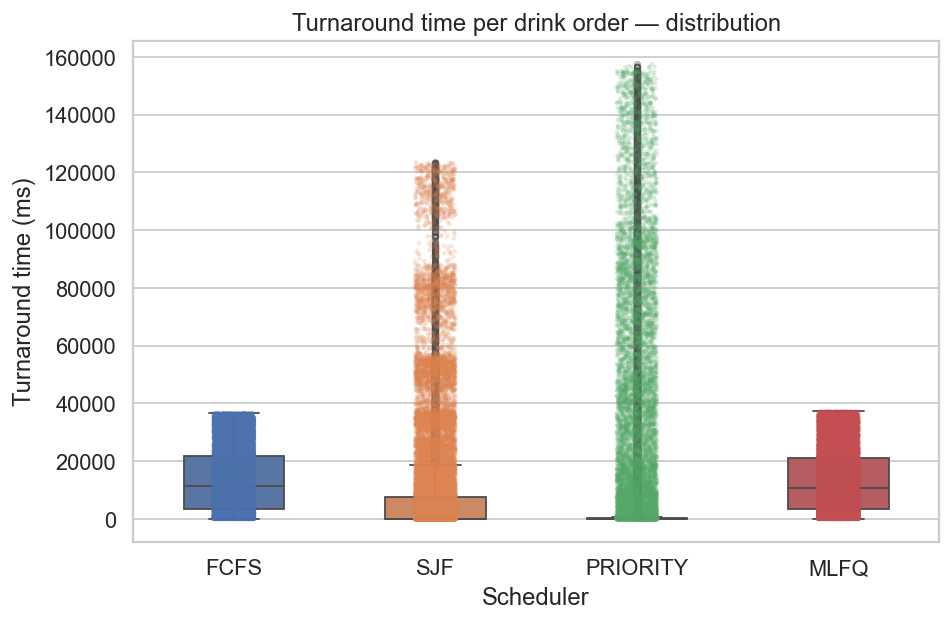

C:\Users\Anele Z Ngxongo\AppData\Local\Temp\ipykernel_53100\4058154933.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="scheduler", y="turnaroundTime", order=SCHEDULER_ORDER,


Saved → plots/turnaroundTime_violin.png


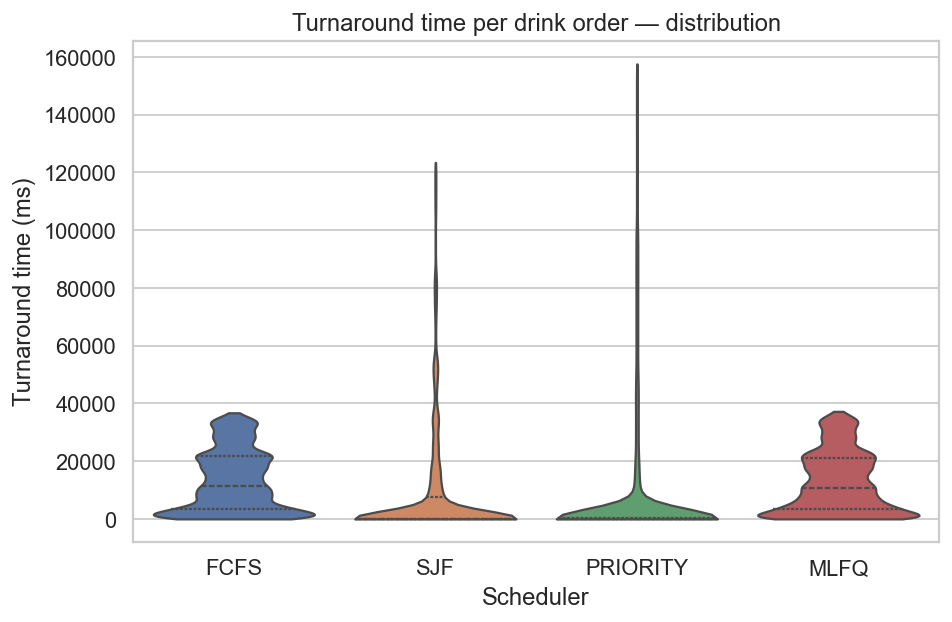

Saved → plots/turnaroundTime_meanmedian.png


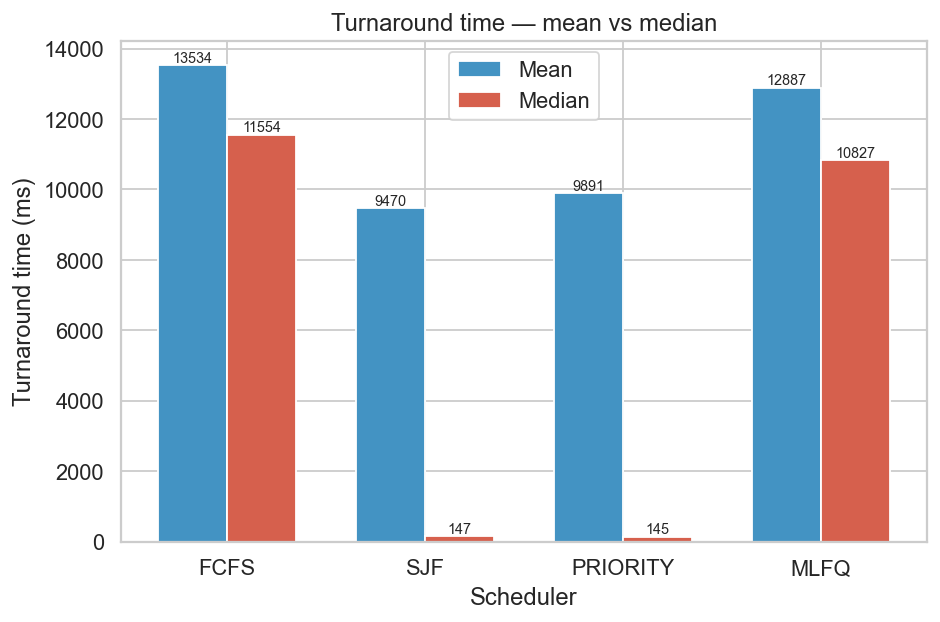

In [6]:
# Box + strip
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df, x="scheduler", y="turnaroundTime", order=SCHEDULER_ORDER,
            palette=PALETTE, width=0.5,
            flierprops={"marker":".", "alpha":0.4}, ax=ax)
sns.stripplot(data=df, x="scheduler", y="turnaroundTime", order=SCHEDULER_ORDER,
              palette=PALETTE, size=2.5, alpha=0.2, jitter=True, ax=ax)
ax.set_title("Turnaround time per drink order — distribution")
ax.set_xlabel("Scheduler"); ax.set_ylabel("Turnaround time (ms)")
save(fig, "turnaroundTime_box.png"); plt.show()

# Violin
fig, ax = plt.subplots(figsize=(8,5))
sns.violinplot(data=df, x="scheduler", y="turnaroundTime", order=SCHEDULER_ORDER,
               palette=PALETTE, inner="quartile", cut=0, ax=ax)
ax.set_title("Turnaround time per drink order — distribution")
ax.set_xlabel("Scheduler"); ax.set_ylabel("Turnaround time (ms)")
save(fig, "turnaroundTime_violin.png"); plt.show()

# Mean vs Median bar
stats = (df.groupby("scheduler", observed=True)["turnaroundTime"]
           .agg(Mean="mean", Median="median")
           .reindex(SCHEDULER_ORDER).reset_index())
fig, ax = plt.subplots(figsize=(8,5))
x, w = np.arange(len(SCHEDULER_ORDER)), 0.35
b1 = ax.bar(x-w/2, stats["Mean"],   w, label="Mean",   color="#4393C3")
b2 = ax.bar(x+w/2, stats["Median"], w, label="Median", color="#D6604D")
ax.set_xticks(x); ax.set_xticklabels(SCHEDULER_ORDER)
ax.set_title("Turnaround time — mean vs median")
ax.set_xlabel("Scheduler"); ax.set_ylabel("Turnaround time (ms)"); ax.legend()
for bar in list(b1)+list(b2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+1, f"{h:.0f}",
            ha="center", va="bottom", fontsize=8)
save(fig, "turnaroundTime_meanmedian.png"); plt.show()

## 6. Per-Patron Total Waiting Time (Fairness)

C:\Users\Anele Z Ngxongo\AppData\Local\Temp\ipykernel_53100\3260331474.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=patron_totals, x="scheduler", y="totalWait",


Saved → plots/patron_total_wait_box.png


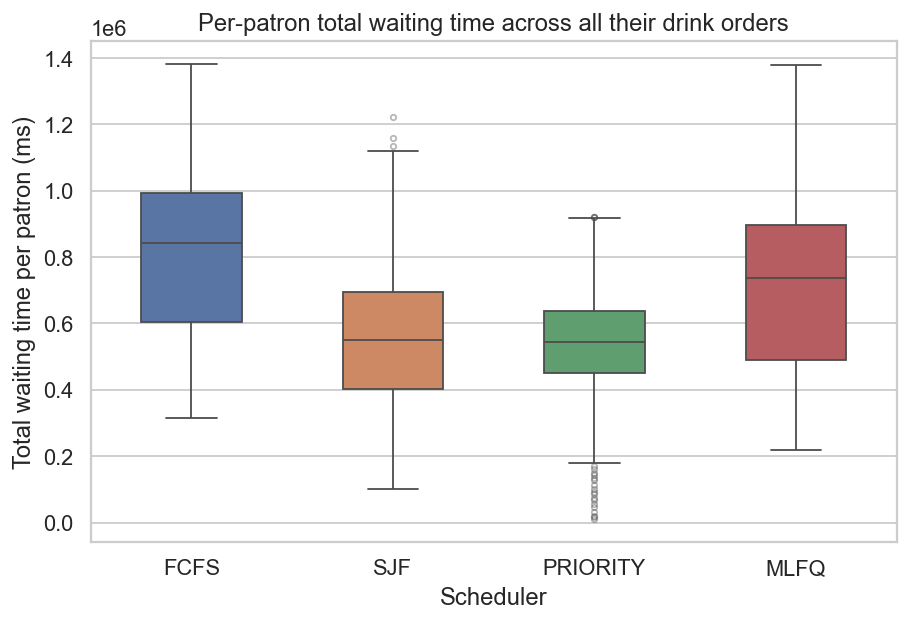

In [7]:
patron_totals = (
    df.groupby(["scheduler","patronID"], observed=True)["waitingTime"]
      .sum().reset_index(name="totalWait")
)
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=patron_totals, x="scheduler", y="totalWait",
            order=SCHEDULER_ORDER, palette=PALETTE, width=0.5,
            flierprops={"marker":".", "alpha":0.4}, ax=ax)
ax.set_title("Per-patron total waiting time across all their drink orders")
ax.set_xlabel("Scheduler"); ax.set_ylabel("Total waiting time per patron (ms)")
save(fig, "patron_total_wait_box.png"); plt.show()

## 7. Throughput

Saved → plots/throughput.png


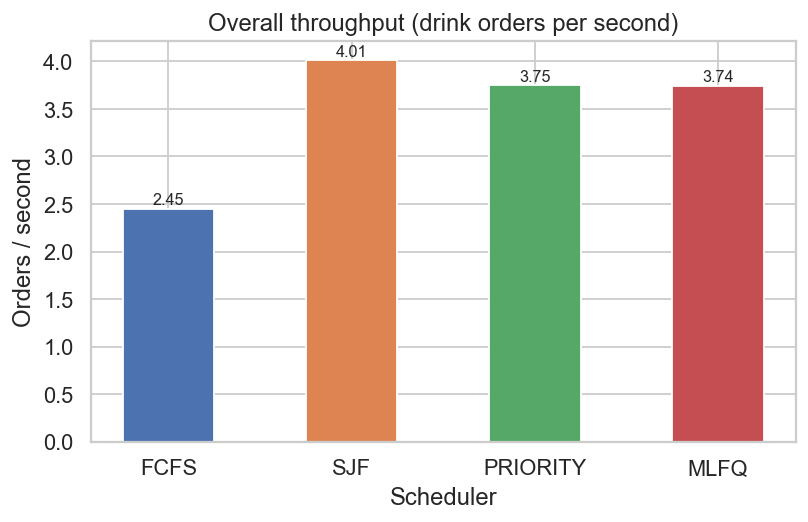

In [8]:
# Throughput per scheduler: total orders / total simulation span (seconds)
rows_tp = []
for sched, g in df.groupby("scheduler", observed=True):
    span_ms = g["completionTime"].max() - g["arrivalTime"].min()
    if span_ms > 0:
        rows_tp.append({"scheduler": sched,
                        "throughput": len(g) / (span_ms / 1000.0)})

tp_df = pd.DataFrame(rows_tp)
tp_df["scheduler"] = pd.Categorical(
    tp_df["scheduler"], categories=SCHEDULER_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(7,4))
colors = [PALETTE[s] for s in tp_df["scheduler"]]
bars = ax.bar(tp_df["scheduler"], tp_df["throughput"], color=colors, width=0.5)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f"{h:.2f}",
            ha="center", va="bottom", fontsize=9)
ax.set_title("Overall throughput (drink orders per second)")
ax.set_xlabel("Scheduler"); ax.set_ylabel("Orders / second")
save(fig, "throughput.png"); plt.show()

## 8. Starvation Check
Mean waiting time per patron ID. In Priority scheduling, higher-ID patrons (lower priority) should show longer waits — a clear upward trend indicates starvation risk.

Saved → plots/starvation_check.png


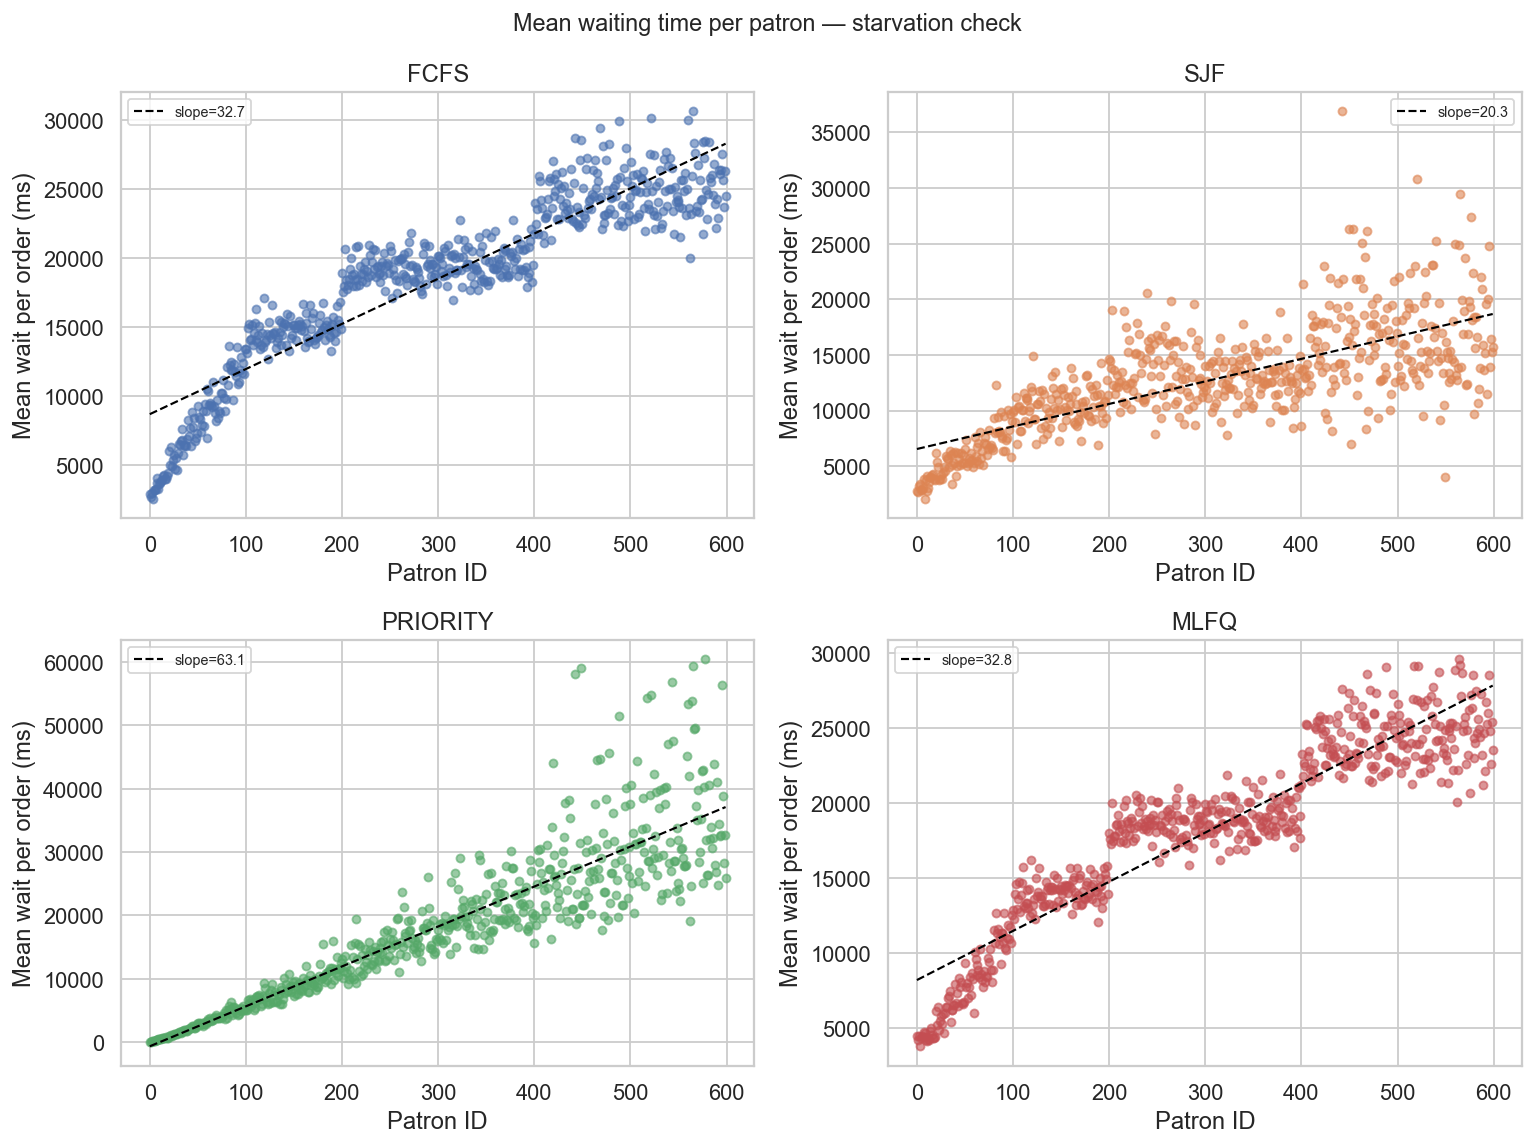

In [9]:
grp = (
    df.groupby(["scheduler","patronID"], observed=True)["waitingTime"]
      .mean().reset_index(name="meanWait")
)
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=False)
axes = axes.flatten()
for i, sched in enumerate(SCHEDULER_ORDER):
    sub = grp[grp["scheduler"] == sched].sort_values("patronID")
    axes[i].scatter(sub["patronID"], sub["meanWait"],
                    color=PALETTE[sched], alpha=0.6, s=20)
    # Trend line
    if len(sub) > 1:
        z = np.polyfit(sub["patronID"], sub["meanWait"], 1)
        p = np.poly1d(z)
        axes[i].plot(sub["patronID"], p(sub["patronID"]),
                     color="black", linewidth=1.2, linestyle="--", label=f"slope={z[0]:.1f}")
        axes[i].legend(fontsize=8)
    axes[i].set_title(sched)
    axes[i].set_xlabel("Patron ID")
    axes[i].set_ylabel("Mean wait per order (ms)")
fig.suptitle("Mean waiting time per patron — starvation check", fontsize=13)
plt.tight_layout()
save(fig, "starvation_check.png"); plt.show()

## 9. Execution Time Distribution by Scheduler
Sanity check — all schedulers should receive the same drink mix (same workload). If the distributions differ significantly, there may be a workload imbalance.

C:\Users\Anele Z Ngxongo\AppData\Local\Temp\ipykernel_53100\3055125878.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="scheduler", y="execTime", order=SCHEDULER_ORDER,


Saved → plots/execTime_distribution.png


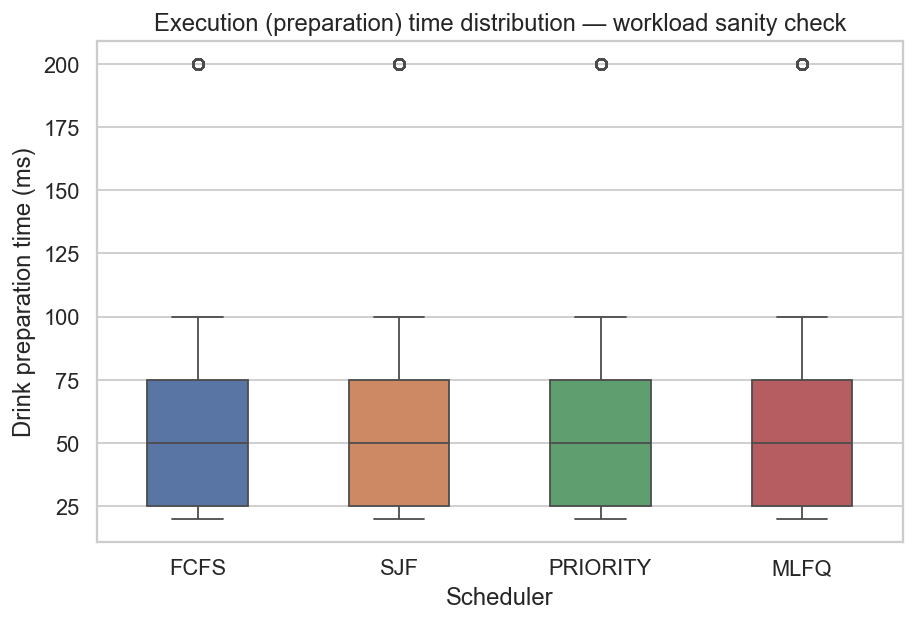

In [10]:
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df, x="scheduler", y="execTime", order=SCHEDULER_ORDER,
            palette=PALETTE, width=0.5, ax=ax)
ax.set_title("Execution (preparation) time distribution — workload sanity check")
ax.set_xlabel("Scheduler"); ax.set_ylabel("Drink preparation time (ms)")
save(fig, "execTime_distribution.png"); plt.show()

Saved → plots/scaling_waiting_linear.png


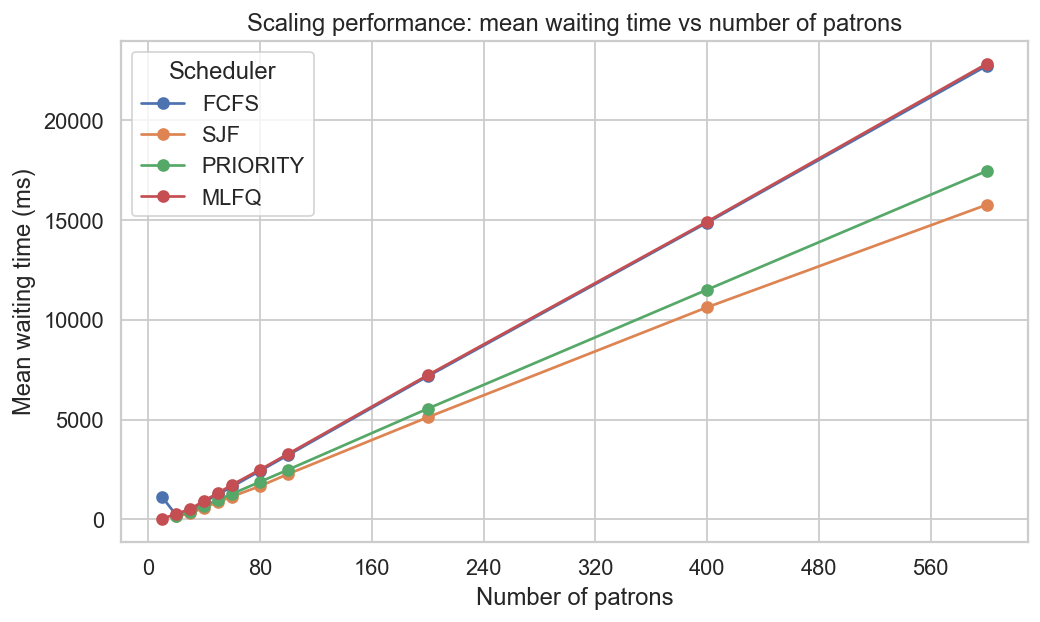

Saved → plots/scaling_waiting_loglog.png


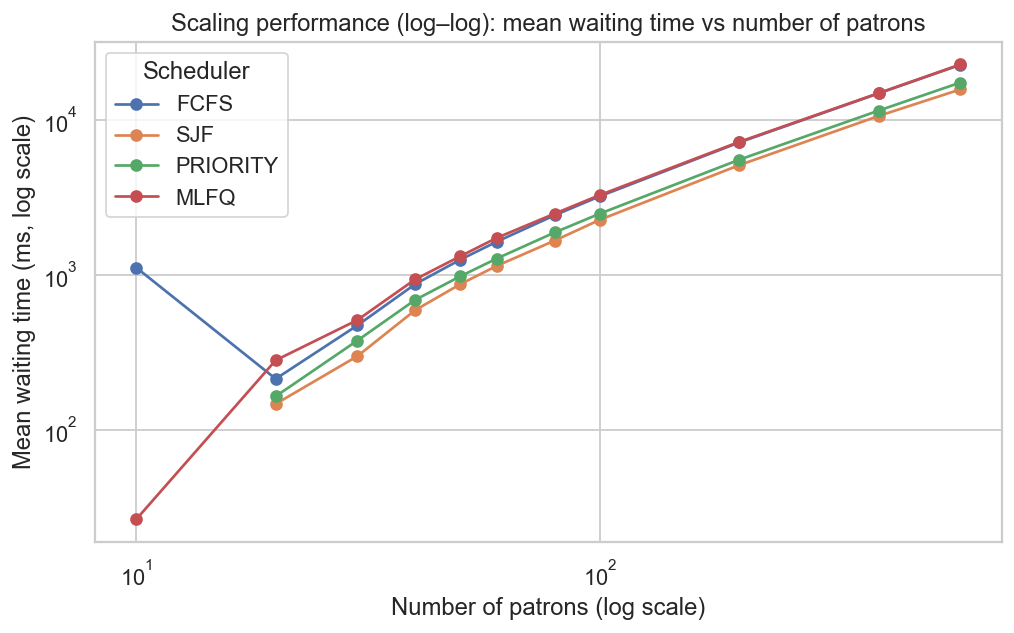

scheduler  noPatrons     meanWait
     FCFS         10  1117.590909
     FCFS         20   213.827119
     FCFS         30   472.745313
     FCFS         40   873.552424
     FCFS         50  1254.133816
     FCFS         60  1641.353767
     FCFS         80  2430.852603
     FCFS        100  3216.645843
     FCFS        200  7166.703728
     FCFS        400 14861.742579
     FCFS        600 22711.191724
      SJF         20   147.302920
      SJF         30   299.198438
      SJF         40   593.108230
      SJF         50   871.306510
      SJF         60  1145.915066
      SJF         80  1667.469589
      SJF        100  2269.019775
      SJF        200  5113.063440
      SJF        400 10622.841156
      SJF        600 15752.745399
 PRIORITY         20   164.889831
 PRIORITY         30   377.351562
 PRIORITY         40   691.182638
 PRIORITY         50   979.828210
 PRIORITY         60  1277.432792
 PRIORITY         80  1882.299178
 PRIORITY        100  2485.622921
 PRIORITY     

In [12]:
## ── Scaling: Mean Waiting Time vs Number of Patrons ──────────────────────

GAP_THRESHOLD = 20_000  # ms — gap between runs in the same CSV file

# Re-load each CSV separately so we can detect run boundaries per scheduler
import glob

scaling_frames = []
for f in glob.glob(os.path.join(RESULTS_DIR, "*.csv")):
    tmp = pd.read_csv(f, skipinitialspace=True)
    for c in ["arrivalTime", "waitingTime", "patronID"]:
        tmp[c] = pd.to_numeric(tmp[c], errors="coerce")
    tmp = tmp.sort_values("arrivalTime").reset_index(drop=True)

    # Find run boundaries: a large gap in arrival time = new simulation run
    gaps   = tmp["arrivalTime"].diff()
    run_id = (gaps > GAP_THRESHOLD).cumsum()
    tmp["run_id"] = run_id

    # noPatrons for each run = highest patron ID in that run + 1
    run_meta = (tmp.groupby("run_id")["patronID"]
                   .max().add(1).rename("noPatrons").reset_index())
    tmp = tmp.merge(run_meta, on="run_id")
    scaling_frames.append(tmp)

sc = pd.concat(scaling_frames, ignore_index=True)
sc["scheduler"] = pd.Categorical(
    sc["scheduler"], categories=SCHEDULER_ORDER, ordered=True)

scaling = (sc.groupby(["scheduler", "noPatrons"], observed=True)["waitingTime"]
             .mean().reset_index(name="meanWait"))

# ── Plot (linear scale) ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for sched in SCHEDULER_ORDER:
    sub = scaling[scaling["scheduler"] == sched].sort_values("noPatrons")
    ax.plot(sub["noPatrons"], sub["meanWait"],
            marker="o", label=sched, color=PALETTE[sched])

ax.set_title("Scaling performance: mean waiting time vs number of patrons")
ax.set_xlabel("Number of patrons")
ax.set_ylabel("Mean waiting time (ms)")
ax.legend(title="Scheduler")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
save(fig, "scaling_waiting_linear.png"); plt.show()

# ── Plot (log-log scale — shows scaling rate more clearly) ────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for sched in SCHEDULER_ORDER:
    sub = scaling[scaling["scheduler"] == sched].sort_values("noPatrons")
    ax.plot(sub["noPatrons"], sub["meanWait"],
            marker="o", label=sched, color=PALETTE[sched])

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("Scaling performance (log–log): mean waiting time vs number of patrons")
ax.set_xlabel("Number of patrons (log scale)")
ax.set_ylabel("Mean waiting time (ms, log scale)")
ax.legend(title="Scheduler")
save(fig, "scaling_waiting_loglog.png"); plt.show()

print(scaling.to_string(index=False))

## Done

In [11]:
saved = sorted(os.listdir(OUT_DIR))
print(f"All done. {len(saved)} files saved to '{OUT_DIR}/':")
for f in saved:
    print(f"  {f}")

All done. 14 files saved to 'plots/':
  execTime_distribution.png
  patron_total_wait_box.png
  responseTime_box.png
  responseTime_meanmedian.png
  responseTime_violin.png
  starvation_check.png
  summary_stats.csv
  throughput.png
  turnaroundTime_box.png
  turnaroundTime_meanmedian.png
  turnaroundTime_violin.png
  waitingTime_box.png
  waitingTime_meanmedian.png
  waitingTime_violin.png
